In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

In [26]:
import pandas as pd

def opening_DIA_files(path='../Workspace_DG/'):
    # Define runs
    runs = [f'run{i}/' for i in range(1, 6)]           # run1 to run5
    runs.extend([f'run{i}/' for i in range(6, 1296)])   # run6 to run99
    # workspace 2 goes to 7262

    # File paths
    stats_files = [path + run + 'stats.txt' for run in runs]

    # for workspace 1 the config files are named default_config
    # for workspace 2 the config files are named config_used
    config_files = [path + run + 'default_config' for run in runs]

    all_stats = []
    all_configs = []

    for i, sf in enumerate(stats_files):
        run_name = runs[i].strip('/')

        # --- Read stats file ---
        df = pd.read_csv(sf, delimiter=' ', header=None)
        df = df.drop(columns=[0, 2]).rename(columns={1: 'mean', 3: 'scatter'})
        df['run'] = run_name
        all_stats.append(df)

        # --- Read config file ---
        config_data = {}
        with open(config_files[i], 'r') as file:
            for line in file:
                line = line.strip('/***')
                part = line.split()
                if '/***' in part:
                    part = part[:part.index('/***')]
                elif '/**' in part:
                    part = part[:part.index('/**')]
                if len(part) >= 2:
                    config_data[part[0]] = part[1]

        config_data['run'] = run_name
        config_df_row = pd.DataFrame([config_data])
        for col in config_df_row.columns:
            if col != 'run':
                config_df_row[col] = pd.to_numeric(config_df_row[col], errors='coerce')

        all_configs.append(config_df_row)

    # --- Combine into single DataFrames ---
    stats_df = pd.concat(all_stats, ignore_index=True).set_index('run')
    config_df = pd.concat(all_configs, ignore_index=True).set_index('run')

    return stats_df, config_df, [r.strip('/') for r in runs]


In [27]:
def Weighted(df):
    weights=1/df['scatter']**2
    weighted_mean=np.sum(weights*df['mean'])/np.sum(weights)
    weighted_std=1/np.sqrt(np.sum(weights))
    return weighted_mean,weighted_std


def Plotting_mean_scatter(ax, df, name='', suffix='', color=None, marker='o'):
    """
    Plot mean with error bars (scatter/std).
    """
    mean_key = f"{suffix + '_' if suffix else ''}mean"
    std_key = f"{suffix + '_' if suffix else ''}scatter"

    x = np.arange(len(df[mean_key]))  # image/run index

    ax.errorbar(
        x, df[mean_key], df[std_key],
        label=name,
        linestyle='-',  # solid line
        marker=marker,
        markersize=2,
        capsize=3,
        elinewidth=1.5,
        markerfacecolor=color,
        markeredgewidth=1,
        color=color,
        alpha=0.8
    )

def plotting_weighted_mean(ax, weighted_df, x_vals=None,color='black', marker='s',color_bar=None):
    """
    Plot weighted means with error bars
    """
    mean_key = 'Weighted_mean'
    std_key = 'Weighted_scatter'
    if x_vals is None:
        x = np.arange(len(weighted_df))
    else:
        x=x_vals
    if color_bar is not None:
        viridis = plt.colormaps['viridis']
        
        # Normalize n_free_parameters to 0-1 for colormap
        norm = plt.Normalize(weighted_df['n_free_parameters'].min(), weighted_df['n_free_parameters'].max())
        
        for xi, yi, yerr, nfp in zip(x, weighted_df[mean_key], weighted_df[std_key], weighted_df['n_free_parameters']):
            ax.errorbar(
                xi, yi, yerr,
                label='Weighted mean' if xi == x[0] else "",  # only label first for legend
                linestyle='dotted', capsize=2, elinewidth=0.8,
                color=viridis(norm(nfp))
            )
    else:
        ax.errorbar(
            x, weighted_df[mean_key], weighted_df[std_key],
            label='Weighted mean',
            linestyle='dotted',capsize=2,elinewidth=0.8,color='k'
        )

# Main plotting of Mean scatter against run

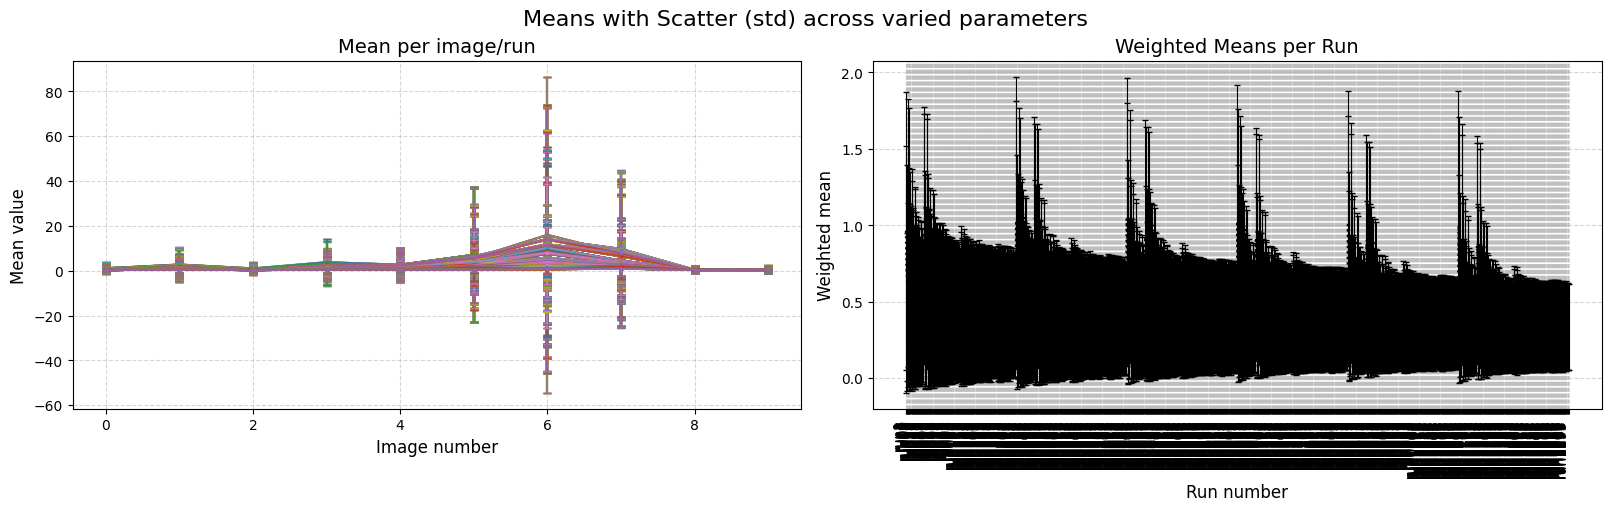

In [28]:


# Load data
stats_df, config_df, runs = opening_DIA_files()

weighted_values = []

fig, ax = plt.subplots(1, 2, figsize=(16, 5), layout='constrained')
colors = plt.cm.tab10.colors  # color cycle

# --- Plot individual run means ---
ax[0].set_title('Mean per image/run', fontsize=14)
ax[0].set_xlabel('Image number', fontsize=12)
ax[0].set_ylabel('Mean value', fontsize=12)
ax[0].grid(True, linestyle='--', alpha=0.5)

for i, run_name in enumerate(runs):
    df_run = stats_df.loc[run_name]          # select all rows for this run
    if isinstance(df_run, pd.Series):
        # Only one row (convert to DataFrame)
        df_run = df_run.to_frame().T
    weighted_values.append(Weighted(df_run))
    Plotting_mean_scatter(
        ax[0],
        df_run,
        name=run_name,
        color=colors[i % len(colors)],
        marker='o'
    )

#ax[0].legend(loc='center left', fontsize=10, frameon=True)

# --- Plot weighted means ---
weighted_values = np.array(weighted_values)
Weighted_df = pd.DataFrame(
    data=weighted_values,
    columns=['Weighted_mean', 'Weighted_scatter'],
    index=[r.strip('/') for r in runs]
)

ax[1].set_title('Weighted Means per Run', fontsize=14)
ax[1].set_xlabel('Run number', fontsize=12)
ax[1].set_ylabel('Weighted mean', fontsize=12)
ax[1].grid(True, linestyle='--', alpha=0.5)

# Use run names as x-axis
plotting_weighted_mean(
    ax[1],
    Weighted_df,
    color='black',
    marker='s'
)
ax[1].set_xticks(np.arange(len(Weighted_df)))
ax[1].set_xticklabels(Weighted_df.index, rotation=90, ha='right')
ax[1].margins(x=0.05)

fig.suptitle('Means with Scatter (std) across varied parameters', fontsize=16)
plt.show()


run
run864     0
run865     0
run866     0
run867     0
run868     0
          ..
run1291    5
run1292    5
run1293    5
run1294    5
run1295    5
Name: deg_gauss1, Length: 432, dtype: int64


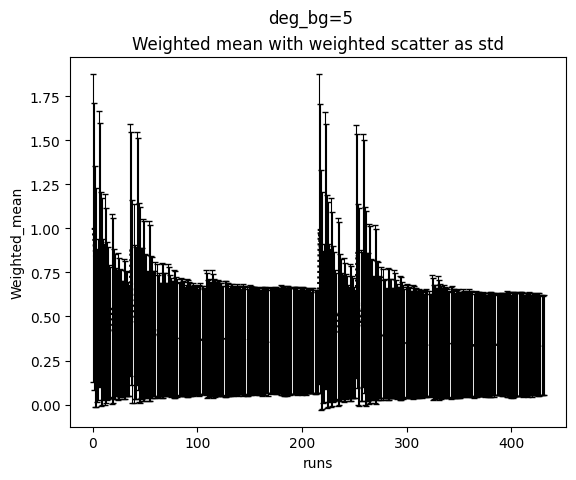

In [29]:

def polynomial_coefficients(order):
    return (order+1)*(order+2)/2


def add_free_parameters(config_df):
    total=(
    polynomial_coefficients(config_df['deg_bg'].astype(float))
    +polynomial_coefficients(config_df['deg_gauss1'].astype(float))
    +polynomial_coefficients(config_df['deg_gauss2'].astype(float))                 
    +polynomial_coefficients(config_df['deg_gauss3'].astype(float))
    +config_df['ngauss'].astype(float)
    )

    config_df['n_free_parameters']=total.astype(int)
    return config_df



Index = config_df[(config_df['deg_bg'] == 4) | (config_df['deg_bg'] == 5)].index
Weights_end_df=Weighted_df.loc[Index]
config_end_df=config_df.loc[Index]

Weights_end_df=Weights_end_df.merge(config_end_df[['deg_bg','deg_gauss1','deg_gauss2','deg_gauss3','ngauss']],left_index=True,right_index=True)
Weights_end_df=add_free_parameters(Weights_end_df)

#print(configs_df)
print(config_end_df['deg_gauss1'])

fig,ax=plt.subplots()
plotting_weighted_mean(
    ax,
    Weights_end_df,
    color='black',
    marker='s',color_bar=None
)

ax.set_xlabel('runs')
ax.set_ylabel('Weighted_mean')
ax.set_title('Weighted mean with weighted scatter as std')
fig.suptitle('deg_bg=5')
plt.show()



need to find the most sensitive parameter and nail that down. then go form there and find the second most sensitive.

    nstamps_x  nstamps_y  sub_x  sub_y  half_mesh_size  half_stamp_size  \
11         10         10      1      1               9               15   

    deg_bg  saturation  pix_min  min_stamp_center  ...  n_free_parameters  \
11       5      230000      5.0               130  ...                 34   

    Weighted_mean  Weighted_scatter  mean_norm  scatter_norm       score  \
11       0.377859          0.352206   0.002173      0.002276  899.149208   

    score_smoothed  diff_n  percentage_diff_score  score_check  
11       928.84886     1.0               0.002082     0.002082  

[1 rows x 28 columns]
    score_check  n_free_parameters        score  score_smoothed
11     0.002082                 34   899.149208      928.848860
24    -0.005483                 47  1018.832146     1029.996271
25     0.006929                 48  1031.740717     1037.133463
28    -0.005843                 51  1037.901760     1036.653420
29    -0.002812                 52  1039.215785     1033.738633
32  

/var/folders/l5/v5dnvp0s55qf8fr_xtcj80w80000gn/T/ipykernel_96305/1479561919.py:76: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  best_per_n['percentage_diff_score'] = best_per_n['score_smoothed'].pct_change()


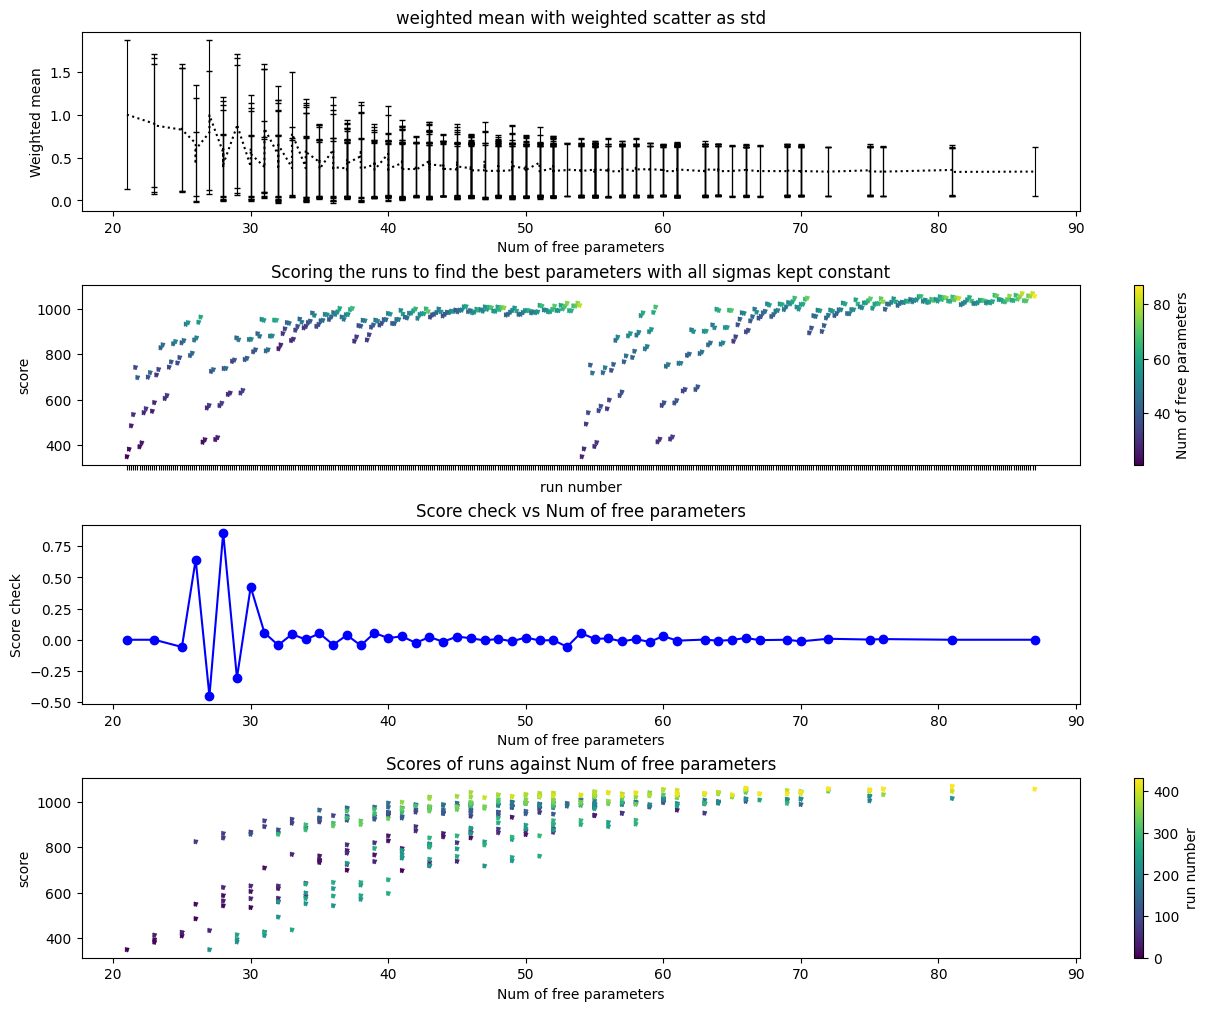

In [30]:
def polynomial_coefficients(order):
    return (order+1)*(order+2)/2


def add_free_parameters(config_df):
    total=(
    polynomial_coefficients(config_df['deg_bg'].astype(float))
    +polynomial_coefficients(config_df['deg_gauss1'].astype(float))
    +polynomial_coefficients(config_df['deg_gauss2'].astype(float))                 
    +polynomial_coefficients(config_df['deg_gauss3'].astype(float))
    +config_df['ngauss'].astype(float)
    )

    config_df['n_free_parameters']=total.astype(int)
    return config_df




# Weights_end_df['mean_norm']=1-(Weights_end_df['Weighted_mean']-Weights_end_df['Weighted_mean'].mean())/ \
#                                (Weights_end_df['Weighted_mean'].max()-Weights_end_df['Weighted_mean'].min())
Weights_end_df['mean_norm'] = [float(i)/sum(Weights_end_df['Weighted_mean']) for i in Weights_end_df['Weighted_mean']]
# Weights_end_df['scatter_norm']=1-(Weights_end_df['Weighted_scatter']-Weights_end_df['Weighted_scatter'].mean())/ \
#                                (Weights_end_df['Weighted_scatter'].max()-Weights_end_df['Weighted_scatter'].min())
Weights_end_df['scatter_norm'] = [float(i)/sum(Weights_end_df['Weighted_scatter']) for i in Weights_end_df['Weighted_scatter']]



config_end_df=add_free_parameters(config_end_df)
order=config_end_df['n_free_parameters'].sort_values().index
config_sorted_end_df=config_end_df.loc[order]
Weights_sorted_end_df=Weights_end_df.loc[order]

fig,ax=plt.subplots(4,layout='constrained',figsize=(12,10))
ax[0].set_xlabel('Num of free parameters')
ax[0].set_ylabel('Weighted mean')
ax[0].set_title('weighted mean with weighted scatter as std')
plotting_weighted_mean(
    ax[0],
    Weights_sorted_end_df,
    x_vals=config_sorted_end_df['n_free_parameters'],
    color='black',
    marker='s'
)

# Weighted_means_order=Weights_end_df['Weighted_mean'].sort_values().index
# config_end_df=config_end_df.loc[order]
# print(config_end_df)


merged = config_end_df.merge(Weights_end_df[['Weighted_mean','Weighted_scatter','mean_norm','scatter_norm']], on='run')

config_plus_meanScatter_df_sorted = merged


# config_plus_meanScatter_df_sorted['score']=(1/config_plus_meanScatter_df_sorted['mean_norm']+1/config_plus_meanScatter_df_sorted['scatter_norm'])*np.exp(-config_plus_meanScatter_df_sorted['n_free_parameters']/100)

config_plus_meanScatter_df_sorted['score']=(1/config_plus_meanScatter_df_sorted['mean_norm']+1/config_plus_meanScatter_df_sorted['scatter_norm'])-(config_plus_meanScatter_df_sorted['n_free_parameters']/(100-config_plus_meanScatter_df_sorted['n_free_parameters']))


# config_plus_meanScatter_df_sorted['score']=np.log1p(1/config_plus_meanScatter_df_sorted['mean_norm']+1/config_plus_meanScatter_df_sorted['scatter_norm'])



config_plus_meanScatter_df_sorted['score_smoothed'] = config_plus_meanScatter_df_sorted['score'].rolling(window=3, center=True).mean()

best_per_n = (
    config_plus_meanScatter_df_sorted
    .sort_values('score', ascending=False)
    .drop_duplicates(subset='n_free_parameters')
    .sort_values('n_free_parameters')
    .reset_index(drop=True)
)

best_per_n['diff_n'] = best_per_n['n_free_parameters'].diff()
best_per_n['percentage_diff_score'] = best_per_n['score_smoothed'].pct_change()

best_per_n['score_check'] = best_per_n['percentage_diff_score'] / best_per_n['diff_n']

best_per_n['score_check'] = best_per_n['score_check'].replace([np.inf, -np.inf], np.nan).fillna(0)

best = best_per_n[(best_per_n['score_check'] < 0.01) & (best_per_n['score_check'] > -0.01) & (best_per_n['score_check'] != 0)]
print(best.head(1))

print(best_per_n[(best_per_n['score_check'] < 0.01) & (best_per_n['score_check'] > -0.01) & (best_per_n['score_check'] != 0)][['score_check', 'n_free_parameters','score','score_smoothed']])


ax[2].set_xlabel('Num of free parameters')
ax[2].set_ylabel('Score check')
ax[2].set_title('Score check vs Num of free parameters')
ax[2].plot(
    best_per_n['n_free_parameters'],
    best_per_n['score_check'],
    marker='o',
    linestyle='-',
    color='blue'
)


def Plotting_score(ax,df,color='black',param=None):
    viridis=plt.colormaps['viridis']

    if param==None:
        x = df.index
        cs=ax.scatter(
        x, df['score'],
        marker='.',
        linestyle='dotted',cmap=viridis,
        c=df['n_free_parameters']
)
    else:
        x=df['n_free_parameters']
        cs=ax.scatter(
        x, df['score'],
        marker='.',
        linestyle='dotted',cmap=viridis,
        c=np.arange(len(df.index))
)
    plt.colorbar(cs,ax=ax,label='Num of free parameters' if param==None else 'run number')
    

ax[1].set_xlabel('run number')
ax[1].set_ylabel('score')
ax[1].set_xticklabels([])
ax[1].set_title('Scoring the runs to find the best parameters with all sigmas kept constant')

Plotting_score(ax[1],config_plus_meanScatter_df_sorted)
Plotting_score(ax[3],config_plus_meanScatter_df_sorted,param=True)
ax[3].set_xlabel('Num of free parameters')
ax[3].set_ylabel('score')
ax[3].set_title('Scores of runs against Num of free parameters')

# plt.colorbar(cmap='viridis',ax=ax[0])
best=config_plus_meanScatter_df_sorted.loc[config_plus_meanScatter_df_sorted['score'].idxmax()]



# Using cumulative improvement threshold

df is sorted according to run number

In [31]:
threshold = 0.01  # 1% improvement
sustain = 8  # number of consecutive steps below threshold

df = config_plus_meanScatter_df_sorted.copy()
consec_below = 0
best_2 = None

def cumulative_improvement(df, start_index, threshold, sustain):
    consec_below = 0
    for i in range(start_index + 1, len(df)):
        rel_improve = (df['score'].iloc[i] - df['score'].iloc[i-1]) / df['score'].iloc[i-1]
        
        if rel_improve < threshold:
            consec_below += 1
        else:
            consec_below = 0
        
        if consec_below >= sustain:
            return df.iloc[i]
    return None



best_bg_4 = cumulative_improvement(df,1, threshold, sustain)
best_bg_5 = cumulative_improvement(df,216, threshold, sustain)


if best_bg_4 is not None:
    print(f"Plateau detected at n = {best_bg_4['n_free_parameters']} with score = {best_bg_4['score']}")
    print(f"Parameters at plateau:\n{best_bg_4[['deg_bg','deg_gauss1','deg_gauss2','deg_gauss3','ngauss']]}")
    print(f"Plateau detected at n = {best_bg_5['n_free_parameters']} with score = {best_bg_5['score']}")
    print(f"Parameters at plateau:\n{best_bg_5[['deg_bg','deg_gauss1','deg_gauss2','deg_gauss3','ngauss']]}")
else:
    print("No plateau detected; all improvements above threshold.")

"""plotting the score and n_free_parameters against run number with vertical lines indicating the plateau points"""

# fig,ax=plt.subplots(1,layout='constrained',figsize=(12,6))
# ax.set_xlabel('runs')
# ax.set_ylabel('score/n_free_parameters')
# ax.set_title(f'Score and n_free_params vs run number with plateau point indicated, sustain={sustain}')
# cs=ax.scatter(config_plus_meanScatter_df_sorted.index,
#            config_plus_meanScatter_df_sorted['score'],
#            marker='.',
#            linestyle='dotted',
#            c=config_plus_meanScatter_df_sorted['n_free_parameters'],
#            cmap='viridis',
#            label='scores'
#            )
# plt.colorbar(cs,ax=ax,label='Num of free parameters')
# ax.plot(config_plus_meanScatter_df_sorted.index,config_plus_meanScatter_df_sorted['n_free_parameters'],color='black',linestyle='-',label='Num of free parameters')
# ax.axvline(x=best_bg_4.name,color='red',linestyle='--',label=f"Plateau score for bg_deg=4:{best_bg_4['score']:.5}")
# ax.axvline(x=best_bg_5.name,color='red',linestyle='--',label=f"Plateau score for bg_deg=5:{best_bg_5['score']:.5}")

# ax.legend()

Plateau detected at n = 40.0 with score = 995.0404789006269
Parameters at plateau:
deg_bg        4.0
deg_gauss1    4.0
deg_gauss2    2.0
deg_gauss3    0.0
ngauss        3.0
Name: run1020, dtype: float64
Plateau detected at n = 46.0 with score = 1041.7579110312179
Parameters at plateau:
deg_bg        5.0
deg_gauss1    4.0
deg_gauss2    2.0
deg_gauss3    0.0
ngauss        3.0
Name: run1236, dtype: float64


'plotting the score and n_free_parameters against run number with vertical lines indicating the plateau points'

# trying to score all the values

In [32]:
# print(f"best parameters: deg_bg={best['deg_bg']},deg_gauss1={best['deg_gauss1']},deg_gauss2={best['deg_gauss2']},deg_gauss3={best['deg_gauss3']}")
print(f"best parameters:sigma_gauss1={best['sigma_gauss1']},sigma_guass2={best['sigma_gauss2']},sigma_gauss3={best['sigma_gauss3']}")

print(best)

print(config_plus_meanScatter_df_sorted['Weighted_mean'].max(),config_plus_meanScatter_df_sorted['Weighted_mean'].min())
print(config_plus_meanScatter_df_sorted['Weighted_scatter'].max(),config_plus_meanScatter_df_sorted['Weighted_scatter'].min())

best parameters:sigma_gauss1=2.0,sigma_guass2=4.0,sigma_gauss3=6.0
nstamps_x                10.000000
nstamps_y                10.000000
sub_x                     1.000000
sub_y                     1.000000
half_mesh_size            9.000000
half_stamp_size          15.000000
deg_bg                    5.000000
saturation           230000.000000
pix_min                   5.000000
min_stamp_center        130.000000
ngauss                    3.000000
deg_gauss1                5.000000
deg_gauss2                5.000000
deg_gauss3                4.000000
sigma_gauss1              2.000000
sigma_gauss2              4.000000
sigma_gauss3              6.000000
deg_spatial               0.000000
n_free_parameters        81.000000
Weighted_mean             0.333552
Weighted_scatter          0.280848
mean_norm                 0.001918
scatter_norm              0.001815
score                  1068.179422
score_smoothed         1060.461938
Name: run1294, dtype: float64
1.0032879787899298 0.3323078

With these parameters, we can then use bayesian optimisation to fit the sigmas and see where the best parameters are this way. Then we do it the other way and compare. We may also run all possible parameters and can compare to that.

### I want to fix all parameters but one and then vary that one to see how it affects the data

# Varying deg_gauss3

keeping deg_gauss1=deg_gauss2=1, deg_gb=5

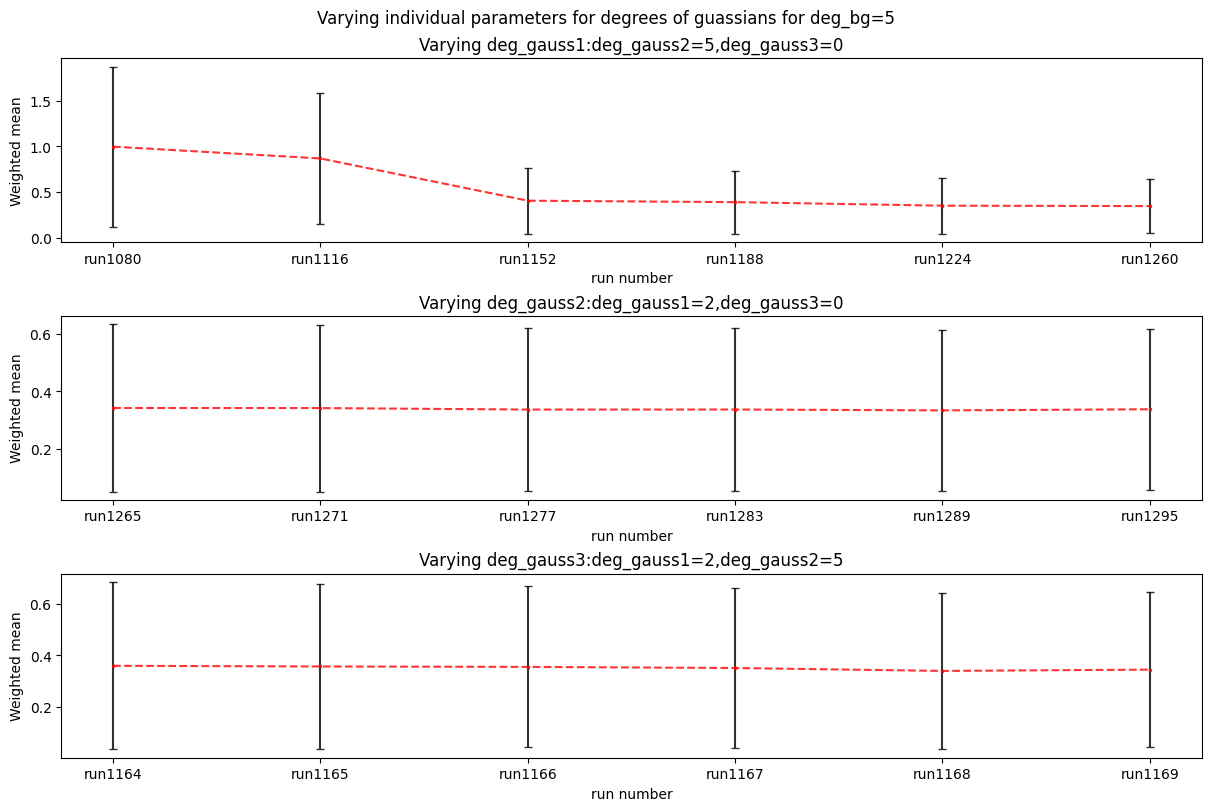

In [33]:
# print(config_end_df)

def varying_parameters(gauss_degs,deg_bg=5):


    Index=config_df[config_df['deg_bg']==deg_bg].index
    Weights_end_df=Weighted_df.loc[Index]
    config_end_df=config_df.loc[Index]

    merged=config_end_df.merge(Weights_end_df[['Weighted_mean','Weighted_scatter']],on='run')

    gauss3_Index=merged[(config_end_df['deg_gauss1']==gauss_degs['deg_gauss1']) &
                        (config_end_df['deg_gauss2']==gauss_degs['deg_gauss1'])].index
    gauss3_merged=merged.loc[gauss3_Index]

    gauss2_Index=merged[(config_end_df['deg_gauss1']==gauss_degs['deg_gauss2']) & 
                        (config_end_df['deg_gauss3']==gauss_degs['deg_gauss2'])].index
    gauss2_merged=merged.loc[gauss2_Index]

    gauss1_Index=merged[(config_end_df['deg_gauss2']==gauss_degs['deg_gauss3']) & 
                        (config_end_df['deg_gauss3']==gauss_degs['deg_gauss3'])].index
    gauss1_merged=merged.loc[gauss1_Index]

    fig,ax=plt.subplots(len(gauss_degs),figsize=(12,8),layout='constrained')

    ax[0].set_xlabel('run number')
    ax[1].set_xlabel('run number')
    ax[2].set_xlabel('run number')
    ax[0].set_ylabel('Weighted mean')
    ax[1].set_ylabel('Weighted mean')
    ax[2].set_ylabel('Weighted mean')
    ax[0].set_title(f"Varying deg_gauss1:deg_gauss2={gauss_degs['deg_gauss2']},deg_gauss3={gauss_degs['deg_gauss3']}")
    ax[1].set_title(f"Varying deg_gauss2:deg_gauss1={gauss_degs['deg_gauss1']},deg_gauss3={gauss_degs['deg_gauss3']}")
    ax[2].set_title(f"Varying deg_gauss3:deg_gauss1={gauss_degs['deg_gauss1']},deg_gauss2={gauss_degs['deg_gauss2']}")
    fig.suptitle(f"Varying individual parameters for degrees of guassians for deg_bg={deg_bg}")

    plotting_with_fixed_parameters(ax[0],gauss1_merged)
    plotting_with_fixed_parameters(ax[1],gauss2_merged)
    plotting_with_fixed_parameters(ax[2],gauss3_merged)


def plotting_with_fixed_parameters(ax,df):
    x = df.index
    ax.errorbar(
        x, df['Weighted_mean'],df['Weighted_scatter'],
        label='Weighted mean',
        linestyle='--',  # solid line
        marker='x',
        markersize=2,
        capsize=3,
        elinewidth=1.5,
        color='red',
        markeredgewidth=1,
        ecolor='k',
        alpha=0.8
    )

gauss_degs={
    'deg_gauss1': 2,
    'deg_gauss2': 5,
    'deg_gauss3': 0
}
varying_parameters(gauss_degs,deg_bg=5)


# Sigma values

3,5.5,9